In [48]:
# Importing All Dependencies
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
# Loading Datsets
df=pd.read_csv(r'C:\Akshay\Data Analytics\Projects Practice\Python EDA\E Commerce\E-Commerce Sales Analytics.csv')

In [59]:
# Initial Exploration of Data
df.info()
df.head()
df.shape
df.tail()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   int64         
 1   order_date        5000 non-null   datetime64[us]
 2   customer_id       5000 non-null   int64         
 3   product_category  5000 non-null   object        
 4   region            5000 non-null   object        
 5   quantity          5000 non-null   int64         
 6   unit_price        5000 non-null   float64       
 7   discount          5000 non-null   float64       
 8   payment_method    5000 non-null   object        
 9   delivery_days     5000 non-null   int64         
 10  customer_rating   5000 non-null   float64       
 11  revenue           5000 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(4), object(3)
memory usage: 468.9+ KB


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
4995,14996,2035-09-05,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74
4996,14997,2035-09-06,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47
4997,14998,2035-09-07,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06
4998,14999,2035-09-08,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38
4999,15000,2035-09-09,1214,Home,East,7,231.58,0.34,COD,5,3.9,1069.90


In [51]:
# Data Cleaning - Finding null values
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [17]:
# Data Cleaning - Finding duplicate values
df.duplicated().sum()

np.int64(0)

In [52]:
# type casting 
# changing data types so that we have uniform and well data format

df['order_date']=pd.to_datetime(df['order_date'])
df['product_category']=df['product_category'].astype("object")
df['region']=df['region'].astype("object")
df['payment_method']=df['payment_method'].astype("object")
df.dtypes

order_id                     int64
order_date          datetime64[us]
customer_id                  int64
product_category            object
region                      object
quantity                     int64
unit_price                 float64
discount                   float64
payment_method              object
delivery_days                int64
customer_rating            float64
revenue                    float64
dtype: object

## Univariate Analysis

In [54]:
# Statistical Summary Analysis
df.describe().round(0)

,order_id,order_date,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.0,5000,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0
mean,12500.0,2028-11-04 12:00:00,1506.0,4.0,308.0,0.0,6.0,3.0,1022.0
min,10001.0,2022-01-01 00:00:00,1000.0,1.0,15.0,0.0,1.0,1.0,11.0
25%,11251.0,2025-06-03 18:00:00,1253.0,2.0,162.0,0.0,3.0,2.0,355.0
50%,12500.0,2028-11-04 12:00:00,1510.0,4.0,310.0,0.0,6.0,3.0,797.0
75%,13750.0,2032-04-07 06:00:00,1761.0,6.0,456.0,0.0,9.0,4.0,1516.0
max,15000.0,2035-09-09 00:00:00,1999.0,7.0,600.0,0.0,11.0,5.0,4119.0
std,1444.0,NaN,291.0,2.0,169.0,0.0,3.0,1.0,826.0


In [55]:
# Idenfying Numerical & Catogorical Columns
numeric_col=['order_id','quantity','unit_price','discount','customer_rating','revenue','delivery_days']
cat_col=['product_category','region','payment_method']

<function matplotlib.pyplot.show(close=None, block=None)>

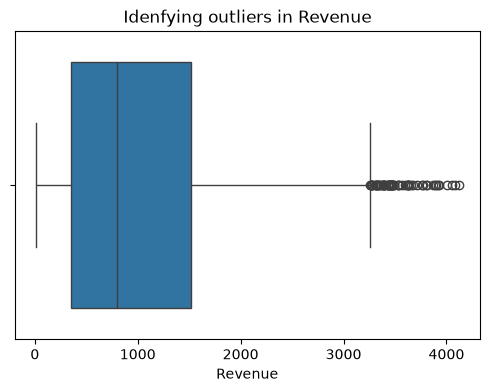

In [56]:
# Idenfying outliers in Revenue
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x='revenue')
plt.title("Idenfying outliers in Revenue")
plt.xlabel("Revenue")
plt.show

From the graph, we can clearly see that there are some sales which have generated some higher revenues than the mean or average revenue.

<function matplotlib.pyplot.show(close=None, block=None)>

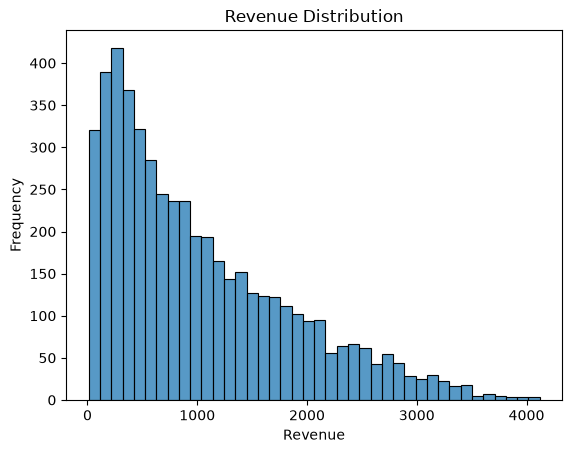

In [45]:
# Revenue Distribution
sns.histplot(data=df,x='revenue', bins=40)
plt.title("Revenue Distribution")
plt.ylabel("Frequency")
plt.xlabel("Revenue")
plt.show

We can see that most of the revenue is generated due to sales between 0 to 2000.

        region
region        
East      1227
North     1276
South     1208
West      1289


<function matplotlib.pyplot.show(close=None, block=None)>

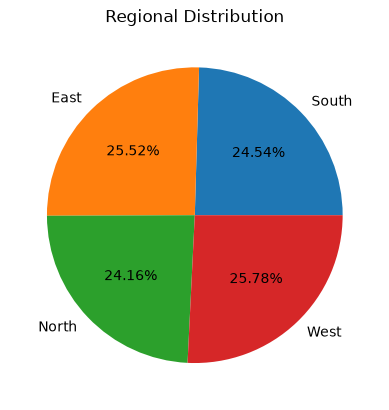

In [57]:
# Regional Distribution
df_category=df.groupby(by='region').agg({'region':'count'})
print(df_category)
label=['South','East','North','West']
plt.pie(data=df_category, x='region', labels=label, autopct='%1.2f%%')
plt.title("Regional Distribution")
plt.show


We can see that revenue is generated uniformly throughout all the regions.

## Bivariate Analysis

<function matplotlib.pyplot.show(close=None, block=None)>

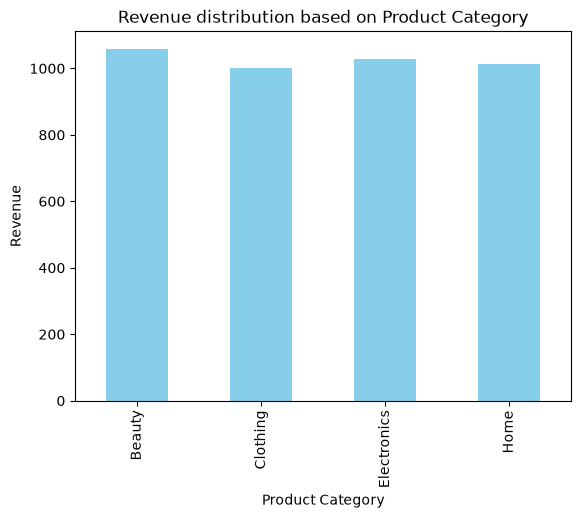

In [61]:
# Revenue distribution based on Product Category
df_category=df.groupby(by='product_category')['revenue'].mean()
df_category.plot(kind='bar', color='skyblue')
plt.title('Revenue distribution based on Product Category')
plt.ylabel("Revenue")
plt.xlabel("Product Category")
plt.show

It clearly seems that the revenue is generated in the following order from product categories -->
Beauty > Electronics > Home > Clothing

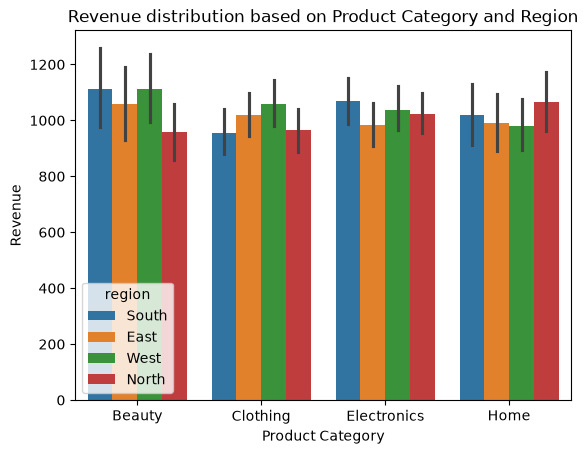

In [60]:
# Revenue distribution based on Product Category and Region
sns.barplot(x='product_category',y='revenue',data=df,hue='region')
plt.title('Revenue distribution based on Product Category and Region')
plt.ylabel("Revenue")
plt.xlabel("Product Category")
plt.show()

It appears that the trend of market is as follows--
Beauty Products- South and West region
Clothing Products- West region
Electronics Products- South region
Home Products- North region

And we can say that East region generates lowest revenue from all the categories.

Text(0.5, 1.0, 'Payment Method Distribution')

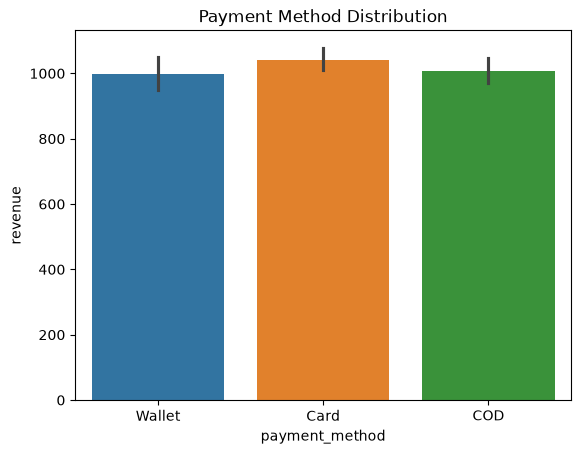

In [13]:
# Payment Method Distribution
sns.barplot(x='payment_method',y='revenue',data=df, hue='payment_method')
plt.title('Payment Method Distribution')

Commonly used payment method is via Card.

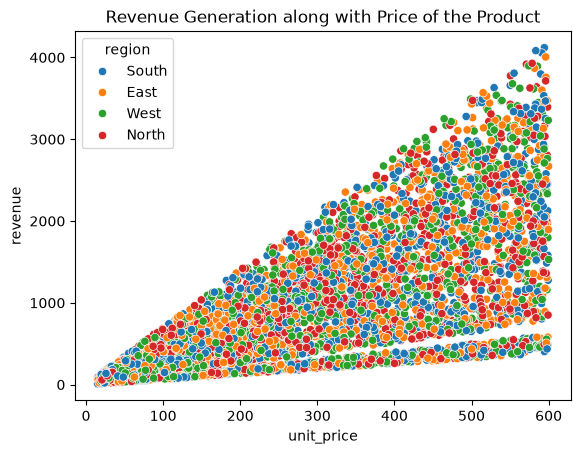

In [62]:
# Revenue Generation along with Price of the Product
sns.scatterplot(x='unit_price',y='revenue',data=df,hue='region')
plt.title('Revenue Generation along with Price of the Product')
plt.show()

The trend is simple - Higher the unit price, Higher the Revenue.

## Multivariate Analysis

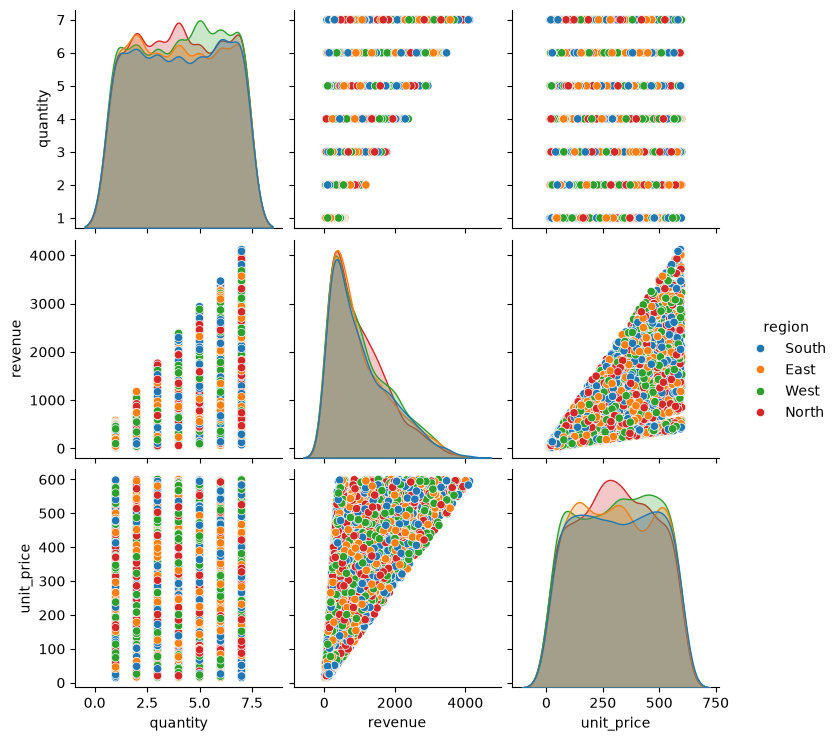

In [29]:
sns.pairplot(data=df,vars=['quantity','revenue','unit_price'] , hue='region')

Products with high unit price and more number of quantities generates more revenue.

In [19]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


<function matplotlib.pyplot.show(close=None, block=None)>

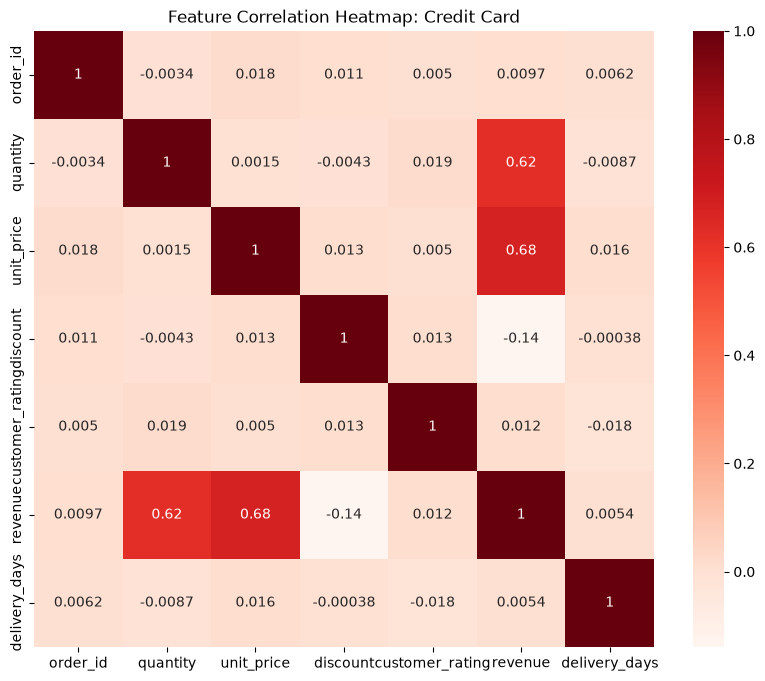

In [47]:
corr_matrix=df[['order_id','quantity','unit_price','discount','customer_rating','revenue','delivery_days']].corr()
corr_matrix
plt.figure(figsize=(10, 8))
plt.title("Feature Correlation Heatmap: Credit Card")
sns.heatmap(data=corr_matrix, annot=True, cmap='Reds')
plt.show

## Overall Conclusion :

The EDA indicates that the e-commerce business has a reasonably diversified and geographically balanced revenue base, but there are clear opportunities to improve revenue through category, regional and order-value optimization.

Beauty is currently the strongest category, particularly in the South and West, while Electronics performs particularly well in the South and Home performs well in the North. Clothing is comparatively weaker overall but shows stronger performance in the West. **The East region is consistently the weakest market**, making it the biggest area requiring further investigation.

Most orders generate relatively moderate revenue, while a smaller number of high-value orders contribute significantly more. Since revenue increases with both unit price and quantity, the business can potentially increase total revenue by **encouraging customers to purchase higher-priced products and larger quantities through bundles, cross-selling and upselling strategies**.

The dominance of card payments also indicates strong adoption of digital payment methods, so the company should continue **optimizing its digital checkout experience**.

🚀 Recommended Business Strategy

1. **Protect the core business**
→ Continue investing in Beauty, the highest-revenue category.

2. **Increase Average Order Value**
→ Use bundles, cross-selling and premium-product recommendations.

3. **Target regions differently**
→ Don't apply one marketing strategy to all regions.

4. **Fix the East-region performance**
→ Analyze pricing, demand, inventory, delivery and marketing separately for East.

5. **Exploit category-region combinations**
→ Push the right products in the regions where they already demonstrate strong demand.

6. **Focus on high-value customers/orders**
→ Identify customers and products associated with high-price/high-quantity purchases and build targeted campaigns around them.

7. **Optimize delivery**
→ Since delivery ranges from 1–11 days, investigate whether longer delivery times are associated with particular regions, categories or high-value orders. This is an important next analysis before making operational decisions.